In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.datasets import fetch_openml


In [3]:
titanic_data = fetch_openml("titanic",version=1,as_frame=True)


In [4]:
df = titanic_data["data"]


In [5]:
df["survived"] = titanic_data["target"]


In [6]:
df.head()


,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON",0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0


<Axes: xlabel='survived', ylabel='count'>

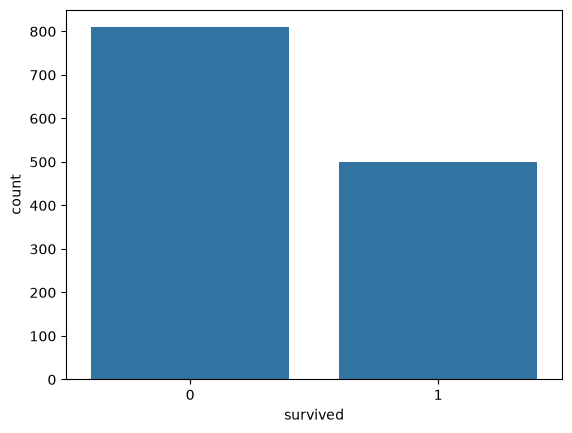

In [7]:
sns.countplot(x="survived",data=df)


<Axes: xlabel='survived', ylabel='count'>

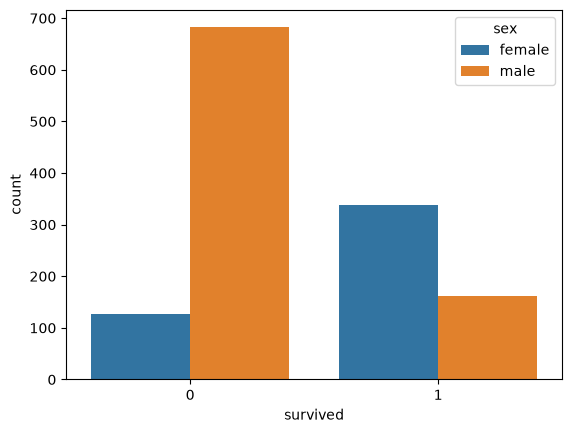

In [8]:
sns.countplot(x="survived",hue="sex", data=df)


<Axes: xlabel='survived', ylabel='count'>

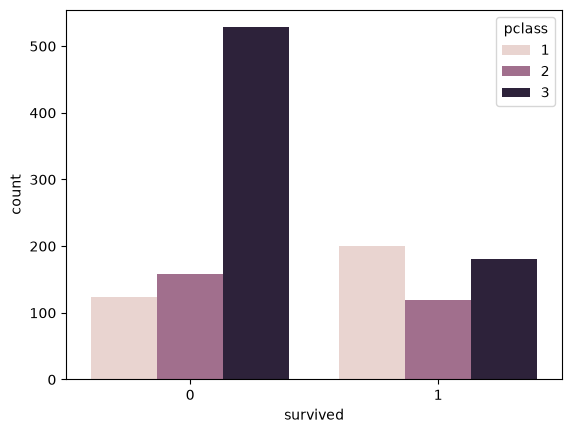

In [9]:
sns.countplot(x="survived", hue="pclass", data=df)


<Axes: ylabel='Frequency'>

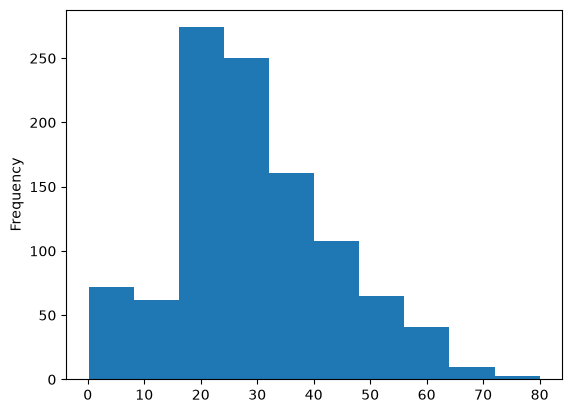

In [10]:
df['age'].plot.hist()


In [11]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1309 non-null   int64   
 1   name       1309 non-null   str     
 2   sex        1309 non-null   category
 3   age        1046 non-null   float64 
 4   sibsp      1309 non-null   int64   
 5   parch      1309 non-null   int64   
 6   ticket     1309 non-null   str     
 7   fare       1308 non-null   float64 
 8   cabin      295 non-null    str     
 9   embarked   1307 non-null   category
 10  boat       486 non-null    str     
 11  body       121 non-null    float64 
 12  home.dest  745 non-null    str     
 13  survived   1309 non-null   category
dtypes: category(3), float64(3), int64(3), str(5)
memory usage: 116.6 KB


In [12]:
df.isnull().sum()


pclass          0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
survived        0
dtype: int64

<Axes: title={'center': 'missing values in percetnage'}, ylabel='%'>

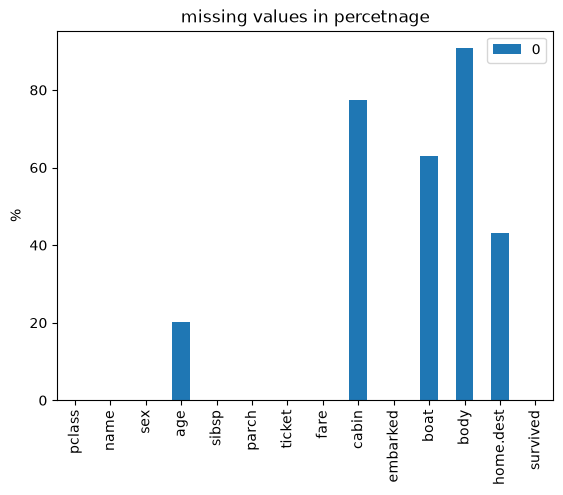

In [13]:
miss_vals = pd.DataFrame(df.isnull().sum()/len(df)*100)

miss_vals.plot(kind='bar',title='missing values in percetnage',ylabel='%')


In [14]:
df['family'] = df['sibsp'] + df['parch']

df.loc[df['family'] >0,'travelled alone'] =0
df.loc[df["family"] ==0, "travelled alone"] = 1


In [15]:
df['family'].head()


0    0
1    3
2    3
3    3
4    3
Name: family, dtype: int64

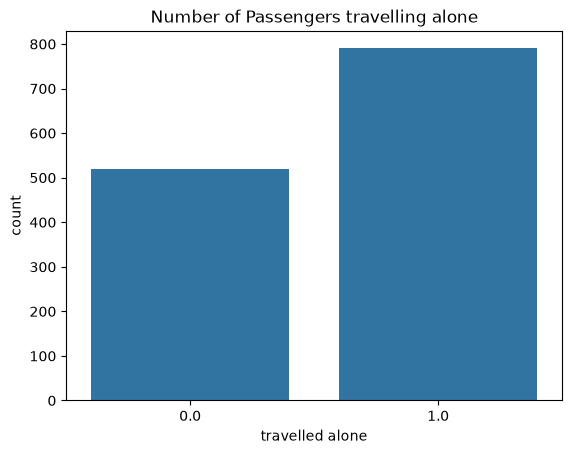

In [16]:
df.drop(['sibsp','parch'],axis=1,inplace=True)

sns.countplot(x='travelled alone',data=df)

plt.title("Number of Passengers travelling alone")
plt.show()


In [17]:
df.head()


,pclass,name,sex,age,ticket,fare,cabin,embarked,boat,body,home.dest,survived,family,travelled alone
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,24160,211.3375,B5,S,2,NaN,"St Louis, MO",1,0,1.0
1,1,"Allison, Master. Hudson Trevor",male,0.9167,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",1,3,0.0
2,1,"Allison, Miss. Helen Loraine",female,2.0000,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0,3,0.0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON",0,3,0.0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0,3,0.0


In [18]:
df.drop(['name','ticket','home.dest'],axis=1,inplace=True)


In [19]:
df.head()


,pclass,sex,age,fare,cabin,embarked,boat,body,survived,family,travelled alone
0,1,female,29.0000,211.3375,B5,S,2,NaN,1,0,1.0
1,1,male,0.9167,151.5500,C22 C26,S,11,NaN,1,3,0.0
2,1,female,2.0000,151.5500,C22 C26,S,NaN,NaN,0,3,0.0
3,1,male,30.0000,151.5500,C22 C26,S,NaN,135.0,0,3,0.0
4,1,female,25.0000,151.5500,C22 C26,S,NaN,NaN,0,3,0.0


In [20]:
df.drop(["body", "boat", "cabin"], axis=1, inplace=True)


In [21]:
df.head()


,pclass,sex,age,fare,embarked,survived,family,travelled alone
0,1,female,29.0000,211.3375,S,1,0,1.0
1,1,male,0.9167,151.5500,S,1,3,0.0
2,1,female,2.0000,151.5500,S,0,3,0.0
3,1,male,30.0000,151.5500,S,0,3,0.0
4,1,female,25.0000,151.5500,S,0,3,0.0


In [22]:
sex=pd.get_dummies(df['sex'],drop_first=True)
print(sex)


       male
0     False
1      True
2     False
3      True
4     False
...     ...
1304  False
1305  False
1306   True
1307   True
1308   True

[1309 rows x 1 columns]


In [23]:
df['sex'] = sex


In [24]:
df.isnull().sum()


pclass               0
sex                  0
age                263
fare                 1
embarked             2
survived             0
family               0
travelled alone      0
dtype: int64

In [25]:
from sklearn.impute import SimpleImputer

imp_mean = SimpleImputer(strategy='mean')



In [26]:
df['age'] = imp_mean.fit_transform(df[['age']])
df["fare"] = imp_mean.fit_transform(df[["fare"]])


In [27]:
df.isnull().sum()


pclass             0
sex                0
age                0
fare               0
embarked           2
survived           0
family             0
travelled alone    0
dtype: int64

In [28]:
imp_freq = SimpleImputer(strategy='most_frequent')


In [29]:
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])


In [30]:
df.isnull().sum()


pclass             0
sex                0
age                0
fare               0
embarked           0
survived           0
family             0
travelled alone    0
dtype: int64

In [31]:
df.head()


,pclass,sex,age,fare,embarked,survived,family,travelled alone
0,1,False,29.0000,211.3375,S,1,0,1.0
1,1,True,0.9167,151.5500,S,1,3,0.0
2,1,False,2.0000,151.5500,S,0,3,0.0
3,1,True,30.0000,151.5500,S,0,3,0.0
4,1,False,25.0000,151.5500,S,0,3,0.0


In [32]:
embark = pd.get_dummies(df['embarked'],drop_first=True)


In [33]:
print(embark)


          Q      S
0     False   True
1     False   True
2     False   True
3     False   True
4     False   True
...     ...    ...
1304  False  False
1305  False  False
1306  False  False
1307  False  False
1308  False   True

[1309 rows x 2 columns]


In [34]:
df.drop(['embarked'],axis=1,inplace=True)

df=pd.concat([df,embark],axis=1)


In [35]:
df.head()


,pclass,sex,age,fare,survived,family,travelled alone,Q,S
0,1,False,29.0000,211.3375,1,0,1.0,False,True
1,1,True,0.9167,151.5500,1,3,0.0,False,True
2,1,False,2.0000,151.5500,0,3,0.0,False,True
3,1,True,30.0000,151.5500,0,3,0.0,False,True
4,1,False,25.0000,151.5500,0,3,0.0,False,True


In [36]:
X = df.drop(['survived'],axis=1)
X.head()


,pclass,sex,age,fare,family,travelled alone,Q,S
0,1,False,29.0000,211.3375,0,1.0,False,True
1,1,True,0.9167,151.5500,3,0.0,False,True
2,1,False,2.0000,151.5500,3,0.0,False,True
3,1,True,30.0000,151.5500,3,0.0,False,True
4,1,False,25.0000,151.5500,3,0.0,False,True


In [37]:
y=df['survived']
y.head()


0    1
1    1
2    0
3    0
4    0
Name: survived, dtype: category
Categories (2, str): ['0', '1']

In [38]:
from sklearn.model_selection import train_test_split


In [39]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=1)


In [40]:
print(X_train.shape,y_train.shape)


(916, 8) (916,)


In [41]:
print(X_test.shape, y_test.shape)


(393, 8) (393,)


In [42]:
from sklearn.linear_model import LogisticRegression

mod = LogisticRegression()
mod.fit(X_train,y_train)


C:\Users\farma\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [43]:
pred = mod.predict(X_test)




In [44]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,pred)


0.7964376590330788

In [45]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test,pred)


array([[204,  32],
       [ 48, 109]])